In [1]:
#!pip install datasets
#!pip install --upgrade --quiet pip
#!pip install --upgrade --quiet datasets[audio] transformers accelerate evaluate jiwer tensorboard gradio
#!pip install --upgrade transformers

In [2]:
import os
import torch

from pathlib import Path

from dataloader import Dataloader
from model_wrapper import WhisperWrapper, IntermediateLayerGetter
from model_evaluator import WhisperEvaluator
from experiment import run_experiment, identify_influential_layers
from feature_density_estimator import FeatureDensityEstimator

avail_dev = torch.device("cuda" if torch.cuda.is_available() else "cpu")
avail_dev = torch.device("xpu" if torch.xpu.is_available() else avail_dev)
print("Using device: ", avail_dev)

Using device:  xpu


In [3]:
#from google.colab import drive
#drive.mount('/content/drive')

#whisper_path = "/content/drive/My Drive/Whisper"
whisper_path = Path(r"C:\Users\erick\Models\Whisper")
print(os.listdir(whisper_path))

['processor_1', 'tokenizer_1', 'whisper_1']


In [4]:
# Create model
model_wrap = WhisperWrapper(model_path=whisper_path, device=avail_dev)
# Create evaluator
whisper_evaluator = WhisperEvaluator(model = model_wrap.model_cond_gen, processor = model_wrap.processor)

In [5]:
# Load baseline data
featured_df, featured_audios = Dataloader.load_dataset_raw_uq(partition_type = "fine_tuning_partition",
                                                              partition_id = "fine_tuning_partition")

Fetching 75 files:   0%|          | 0/75 [00:00<?, ?it/s]

In [6]:
# Get all the layers
layer_names = IntermediateLayerGetter.get_layer_names(model_wrap.model)
# Select only the layer norms
layer_names = [name for name in layer_names if (("layer_norm" in name) and not("attn" in name))]
# Get the layer influence scores
layer_influence_score = identify_influential_layers(model_wrap, layer_names, featured_audios)

print("Most influential layers:")
print(60*"-")
for key, value in layer_influence_score.items():
    print(f"{key}:\t\t{value:.4f}")
    print(60*"-")

Processing baseline audios:   0%|          | 0/2000 [00:00<?, ?it/s]

Passing a tuple of `past_key_values` is deprecated and will be removed in Transformers v4.43.0. You should pass an instance of `EncoderDecoderCache` instead, e.g. `past_key_values=EncoderDecoderCache.from_legacy_cache(past_key_values)`.


Most influential layers:
------------------------------------------------------------
decoder.layers.0.final_layer_norm:		0.7894
------------------------------------------------------------
decoder.layers.2.final_layer_norm:		0.6350
------------------------------------------------------------
decoder.layers.11.final_layer_norm:		0.5567
------------------------------------------------------------
decoder.layers.5.final_layer_norm:		0.5252
------------------------------------------------------------
decoder.layers.4.final_layer_norm:		0.5117
------------------------------------------------------------
decoder.layers.1.final_layer_norm:		0.4939
------------------------------------------------------------
encoder.layers.0.final_layer_norm:		0.4923
------------------------------------------------------------
decoder.layers.3.final_layer_norm:		0.4725
------------------------------------------------------------
decoder.layers.7.final_layer_norm:		0.4308
--------------------------------------

In [7]:
print(list(layer_influence_score.keys())) 

['decoder.layers.0.final_layer_norm', 'decoder.layers.2.final_layer_norm', 'decoder.layers.11.final_layer_norm', 'decoder.layers.5.final_layer_norm', 'decoder.layers.4.final_layer_norm', 'decoder.layers.1.final_layer_norm', 'encoder.layers.0.final_layer_norm', 'decoder.layers.3.final_layer_norm', 'decoder.layers.7.final_layer_norm', 'decoder.layers.6.final_layer_norm', 'decoder.layers.10.final_layer_norm', 'encoder.layers.1.final_layer_norm', 'encoder.layers.2.final_layer_norm', 'encoder.layers.3.final_layer_norm', 'decoder.layers.8.final_layer_norm', 'decoder.layers.9.final_layer_norm', 'encoder.layers.4.final_layer_norm', 'encoder.layers.6.final_layer_norm', 'encoder.layers.11.final_layer_norm', 'encoder.layers.5.final_layer_norm', 'encoder.layers.10.final_layer_norm', 'encoder.layers.7.final_layer_norm', 'encoder.layers.8.final_layer_norm', 'encoder.layers.9.final_layer_norm', 'encoder.layer_norm', 'decoder.layer_norm']


In [8]:
#calibration_ds, calibration_audios = Dataloader.load_uq_partitions("calibration")
#finetune_ds, finetune_audios = Dataloader.load_uq_partitions("fine-tune")
test_ds, test_audios = Dataloader.load_uq_partitions("test", 1, 11)

Fetching 75 files:   0%|          | 0/75 [00:00<?, ?it/s]

Fetching 75 files:   0%|          | 0/75 [00:00<?, ?it/s]

Fetching 75 files:   0%|          | 0/75 [00:00<?, ?it/s]

Fetching 75 files:   0%|          | 0/75 [00:00<?, ?it/s]

Fetching 75 files:   0%|          | 0/75 [00:00<?, ?it/s]

Fetching 75 files:   0%|          | 0/75 [00:00<?, ?it/s]

Fetching 75 files:   0%|          | 0/75 [00:00<?, ?it/s]

Fetching 75 files:   0%|          | 0/75 [00:00<?, ?it/s]

Fetching 75 files:   0%|          | 0/75 [00:00<?, ?it/s]

Fetching 75 files:   0%|          | 0/75 [00:00<?, ?it/s]

In [9]:
# Validate that using .last_hidden_state is equal to using the layer name
"""input_features = model_wrap.feature_extractor(test_audios[0][0], return_tensors="pt", sampling_rate = model_wrap.sampling_rate).input_features.to(avail_dev)
decoder_input_ids = torch.tensor([[1, 1]], device=avail_dev) * model_wrap.model.config.decoder_start_token_id
by_attr = model_wrap.model(input_features, decoder_input_ids = decoder_input_ids).last_hidden_state
by_hook = hooked_model(input_features, decoder_input_ids = decoder_input_ids)[0]
print("By attr: ", by_attr.shape)
print("By hook: ", by_hook["decoder.layer_norm"].shape)
print(torch.equal(by_attr, by_hook["decoder.layer_norm"]))"""

'input_features = model_wrap.feature_extractor(test_audios[0][0], return_tensors="pt", sampling_rate = model_wrap.sampling_rate).input_features.to(avail_dev)\ndecoder_input_ids = torch.tensor([[1, 1]], device=avail_dev) * model_wrap.model.config.decoder_start_token_id\nby_attr = model_wrap.model(input_features, decoder_input_ids = decoder_input_ids).last_hidden_state\nby_hook = hooked_model(input_features, decoder_input_ids = decoder_input_ids)[0]\nprint("By attr: ", by_attr.shape)\nprint("By hook: ", by_hook["decoder.layer_norm"].shape)\nprint(torch.equal(by_attr, by_hook["decoder.layer_norm"]))'

Extracting embeddings:   0%|          | 0/2000 [00:00<?, ?it/s]

Processing partitions:   0%|          | 0/10 [00:00<?, ?it/s]

Evaluating likelihood:   0%|          | 0/120 [00:00<?, ?it/s]

Tanscribing audio:   0%|          | 0/120 [00:00<?, ?it/s]

You have passed task=transcribe, but also have set `forced_decoder_ids` to [(1, 50262), (2, 50359), (3, 50363)] which creates a conflict. `forced_decoder_ids` will be ignored in favor of task=transcribe.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
c:\Users\erick\micromamba\envs\ml\lib\site-packages\transformers\pytorch_utils.py:334: UserWarning: Aten Op fallback from XPU to CPU happends. This may have performance implications. If need debug the fallback ops please set environment variable `PYTORCH_DEBUG_XPU_FALLBACK=1`  (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\build\aten\src\ATen\xpu\RegisterXPU.cpp:7617.)
  return torch.isin(elements, test_elements)


Partition 0 - Mean WER: 0.2190, Std WER: 0.1717, Pearson correlation coefficient: -0.3463


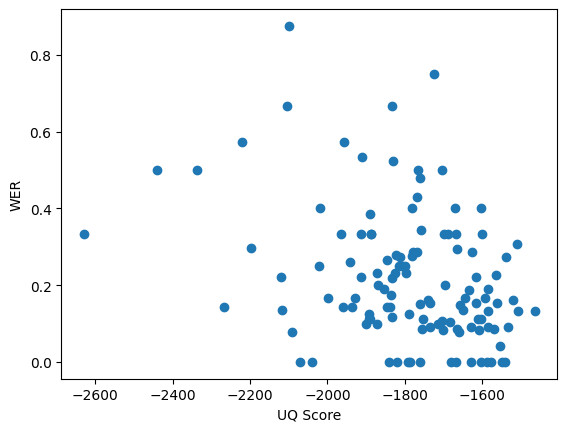

Evaluating likelihood:   0%|          | 0/120 [00:00<?, ?it/s]

Tanscribing audio:   0%|          | 0/120 [00:00<?, ?it/s]

Partition 1 - Mean WER: 0.2813, Std WER: 0.8231, Pearson correlation coefficient: -0.3325


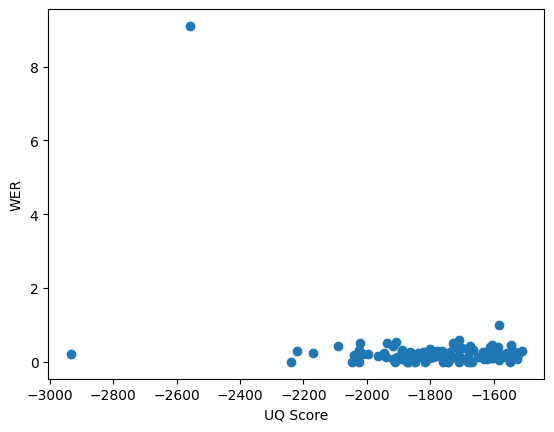

Evaluating likelihood:   0%|          | 0/120 [00:00<?, ?it/s]

Tanscribing audio:   0%|          | 0/120 [00:00<?, ?it/s]

Partition 2 - Mean WER: 0.3054, Std WER: 0.8284, Pearson correlation coefficient: -0.2328


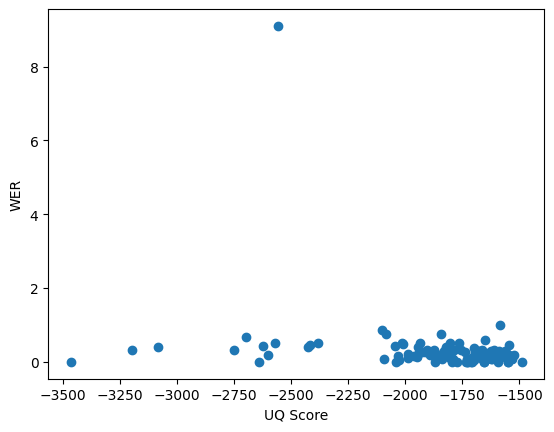

Evaluating likelihood:   0%|          | 0/120 [00:00<?, ?it/s]

Tanscribing audio:   0%|          | 0/120 [00:00<?, ?it/s]

Partition 3 - Mean WER: 0.2060, Std WER: 0.1403, Pearson correlation coefficient: -0.2342


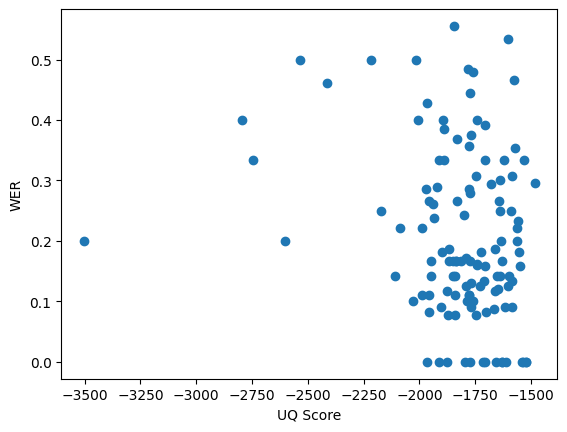

Evaluating likelihood:   0%|          | 0/120 [00:00<?, ?it/s]

Tanscribing audio:   0%|          | 0/120 [00:00<?, ?it/s]

Partition 4 - Mean WER: 0.2912, Std WER: 0.8247, Pearson correlation coefficient: -0.2326


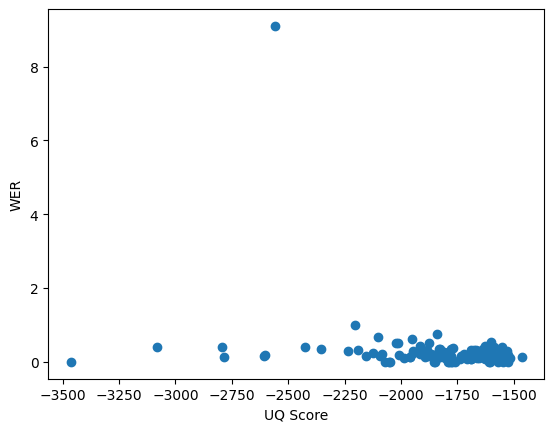

Evaluating likelihood:   0%|          | 0/120 [00:00<?, ?it/s]

Tanscribing audio:   0%|          | 0/120 [00:00<?, ?it/s]

Partition 5 - Mean WER: 0.2267, Std WER: 0.1841, Pearson correlation coefficient: -0.4117


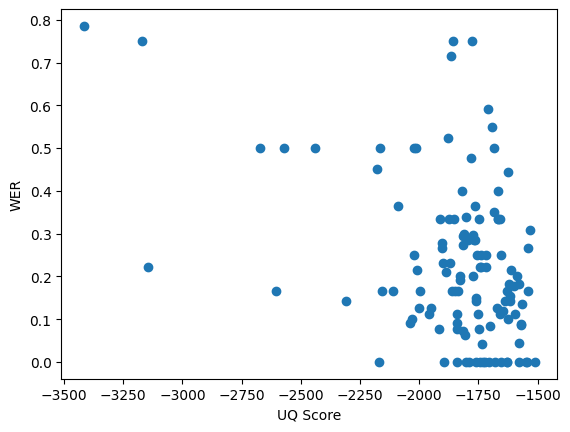

Evaluating likelihood:   0%|          | 0/120 [00:00<?, ?it/s]

Tanscribing audio:   0%|          | 0/120 [00:00<?, ?it/s]

Partition 6 - Mean WER: 0.2377, Std WER: 0.2023, Pearson correlation coefficient: -0.4870


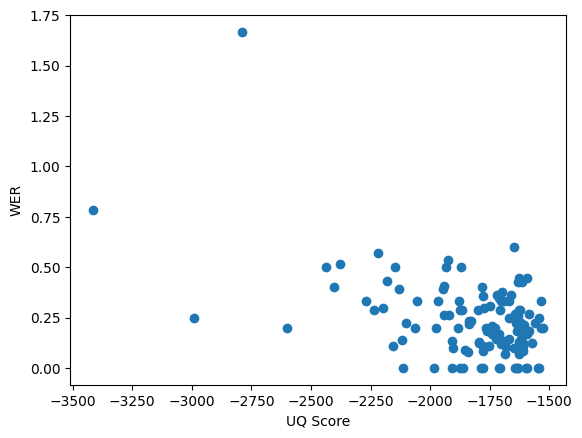

Evaluating likelihood:   0%|          | 0/120 [00:00<?, ?it/s]

Tanscribing audio:   0%|          | 0/120 [00:00<?, ?it/s]

Partition 7 - Mean WER: 0.2334, Std WER: 0.1984, Pearson correlation coefficient: -0.3813


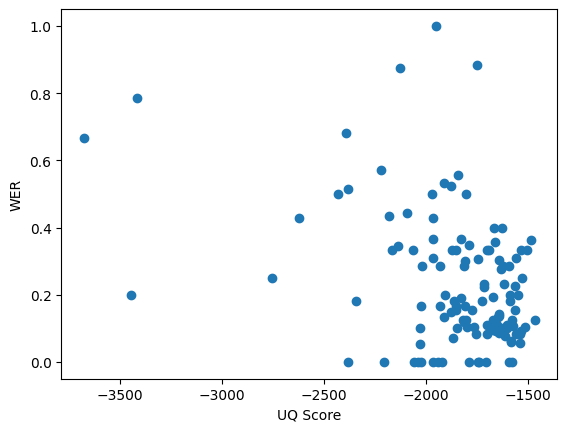

Evaluating likelihood:   0%|          | 0/120 [00:00<?, ?it/s]

Tanscribing audio:   0%|          | 0/120 [00:00<?, ?it/s]

Partition 8 - Mean WER: 0.2171, Std WER: 0.1766, Pearson correlation coefficient: -0.3750


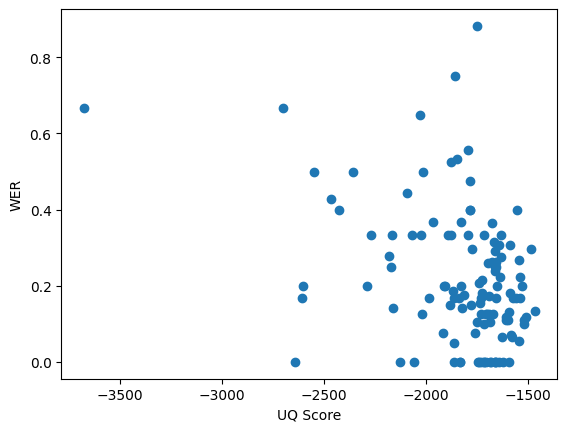

Evaluating likelihood:   0%|          | 0/120 [00:00<?, ?it/s]

Tanscribing audio:   0%|          | 0/120 [00:00<?, ?it/s]

Partition 9 - Mean WER: 0.2276, Std WER: 0.1884, Pearson correlation coefficient: -0.2105


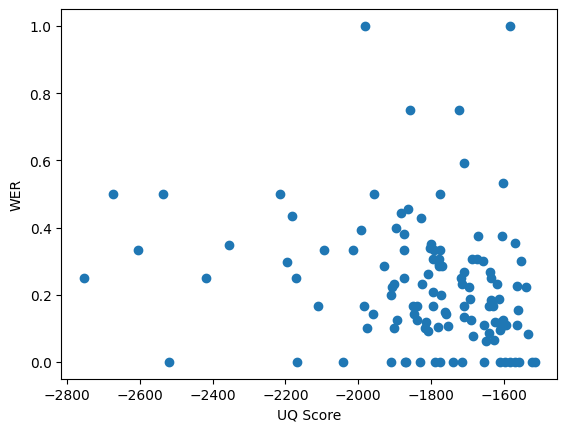

=============== Results ===============
    Partition         R  Mean WER   Std WER
0          0 -0.346259  0.218966  0.171679
1          1 -0.332527  0.281326  0.823102
2          2 -0.232771  0.305386  0.828395
3          3 -0.234214  0.205980  0.140332
4          4 -0.232567  0.291216  0.824666
5          5 -0.411651  0.226660  0.184113
6          6 -0.486964  0.237704  0.202348
7          7 -0.381325  0.233382  0.198414
8          8 -0.374964  0.217066  0.176632
9          9 -0.210470  0.227627  0.188354
=============== Mean results ===============
 Partition    4.500000
R           -0.324371
Mean WER     0.244531
Std WER      0.373804
dtype: float64


<Figure size 640x480 with 0 Axes>

In [ ]:
# Default usecase (last_hidden_state[0, 0, :])
fde = FeatureDensityEstimator(model_wrap)
default_tl = ["decoder.layer_norm"]
default_ef = lambda x: x[0, 0, :].cpu().detach()
kwargs = {  "target_layers":      default_tl,
            "embedding_filter":   default_ef
        }

run_experiment( fde, whisper_evaluator, featured_audios, test_ds, test_audios,
                "baseline-last_hidden_state", "results/baseline-last_hidden_state", **kwargs)

In [ ]:
# Multiple layers single channel (last_hidden_state[0, 0, :])
fde = FeatureDensityEstimator(model_wrap)
kwargs = {  "target_layers":      ['decoder.layers.0.final_layer_norm', 'decoder.layers.2.final_layer_norm', 
                                   'decoder.layers.11.final_layer_norm', 'decoder.layers.5.final_layer_norm', 
                                   'decoder.layers.4.final_layer_norm'],
            "embedding_filter":   lambda x: x[0, 0, :].cpu().detach()
        }

run_experiment( fde, whisper_evaluator, featured_audios, test_ds, test_audios,
                "top_5_layers-last_hidden_state", "results/top_5_layers-last_hidden_state", **kwargs)